In [82]:
import xarray as xr

# Open the Zarr store
#ds = xr.open_zarr('/ec/res4/scratch/smcd/output/yarong_data/cera_era5_128x128', consolidated=True)
ds = xr.open_zarr('/lus/h2resw01/scratch/swe4281/CERRA_DATA2026/zarr-out_2015-2024', consolidated=True)
ds = xr.open_zarr('/ec/res4/scratch/smcd/output/yarong_data/cera_era5_256x256.zarr', consolidated=True, zarr_format=2)


print(ds)
print("\nVariables:", list(ds.data_vars))
#print("Time steps:", ds.valid_time.values)
#print(ds["mean"].values)

#[2.82283539e+02 4.61665988e-01 2.82755422e+02 2.02493479e-01]
#[2.74791809e+02 4.54366356e-01 2.75094463e+02 2.67753382e-01]
#[2.80183533e+02 4.65650141e-01 2.80655297e+02 2.05893074e-01]

<xarray.Dataset> Size: 6GB
Dimensions:         (variable: 4, valid_time: 3653, y: 256, x: 256)
Coordinates:
  * variable        (variable) <U14 224B 't2m_cerra_mean' ... 't2m_era5_std'
  * valid_time      (valid_time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
  * y               (y) int64 2kB 0 1 2 3 4 5 6 ... 249 250 251 252 253 254 255
  * x               (x) int64 2kB 0 1 2 3 4 5 6 ... 249 250 251 252 253 254 255
    latitude        (y, x) float64 524kB dask.array<chunksize=(256, 256), meta=np.ndarray>
    longitude       (y, x) float64 524kB dask.array<chunksize=(256, 256), meta=np.ndarray>
Data variables:
    max             (variable) float64 32B dask.array<chunksize=(4,), meta=np.ndarray>
    mean            (variable) float64 32B dask.array<chunksize=(4,), meta=np.ndarray>
    min             (variable) float64 32B dask.array<chunksize=(4,), meta=np.ndarray>
    std             (variable) float64 32B dask.array<chunksize=(4,), meta=np.ndarray>
    t2m_cerra_mean  (valid_tim

In [ ]:
def check_for_nans(obj):
    """
    Checks if an Xarray Dataset or DataArray contains any NaN values.
    Returns a dictionary with results per variable if it's a Dataset.
    """
    if isinstance(obj, xr.DataArray):
        nan_count = obj.isnull().sum().compute().item()
        has_nans = nan_count > 0
        print(f"Variable '{obj.name}': {nan_count} NaNs found. (Has NaNs: {has_nans})")
        return has_nans
    
    elif isinstance(obj, xr.Dataset):
        results = {}
        print("Checking Dataset variables for NaNs...")
        for var in obj.data_vars:
            nan_count = obj[var].isnull().sum().compute().item()
            results[var] = nan_count > 0
            print(f" - {var}: {nan_count} NaNs")
        return results

In [75]:
check_for_nans(ds)


Checking Dataset variables for NaNs...
 - max: 0 NaNs
 - mean: 0 NaNs
 - min: 0 NaNs
 - std: 0 NaNs
 - t2m_cerra_mean: 0 NaNs
 - t2m_cerra_std: 0 NaNs
 - t2m_era5_mean: 0 NaNs
 - t2m_era5_std: 0 NaNs


{'max': False,
 'mean': False,
 'min': False,
 'std': False,
 't2m_cerra_mean': False,
 't2m_cerra_std': False,
 't2m_era5_mean': False,
 't2m_era5_std': False}

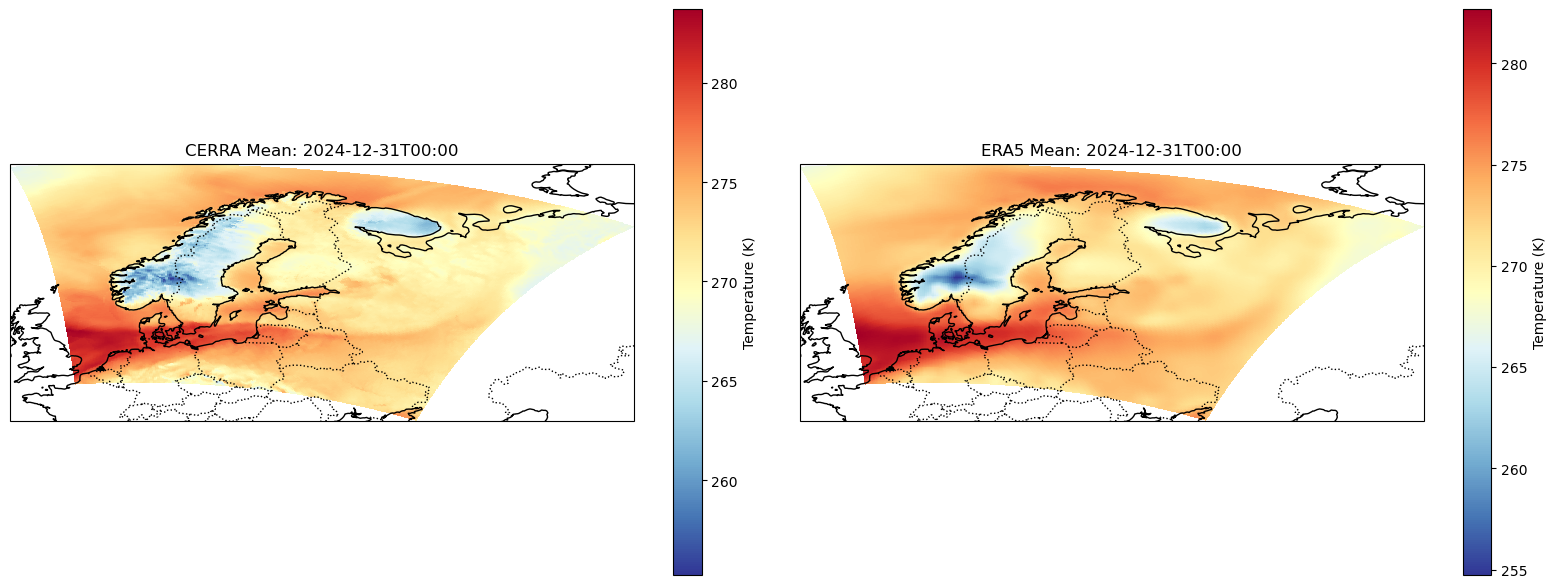

In [80]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select a specific time index (e.g., the first one)
time_idx = 3652
time_str = str(ds.valid_time.isel(valid_time=time_idx).values)[:16]

# Create subplot with projection
fig, ax = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()})


# Plot CERRA Mean
ds['t2m_cerra_mean'].isel(valid_time=time_idx).plot(
    ax=ax[0], 
    x='longitude', y='latitude', 
    transform=ccrs.PlateCarree(), 
    cmap='RdYlBu_r',
    cbar_kwargs={'label': 'Temperature (K)'}
)
ax[0].set_title(f"CERRA Mean: {time_str}")

# Plot ERA5 Mean
ds['t2m_era5_mean'].isel(valid_time=time_idx).plot(
    ax=ax[1], 
    x='longitude', y='latitude', 
    transform=ccrs.PlateCarree(), 
    cmap='RdYlBu_r',
    cbar_kwargs={'label': 'Temperature (K)'}
)
ax[1].set_title(f"ERA5 Mean: {time_str}")

# Add coastlines
for a in ax:
    a.coastlines()
    a.add_feature(cfeature.BORDERS, linestyle=':')

plt.tight_layout()
plt.show()

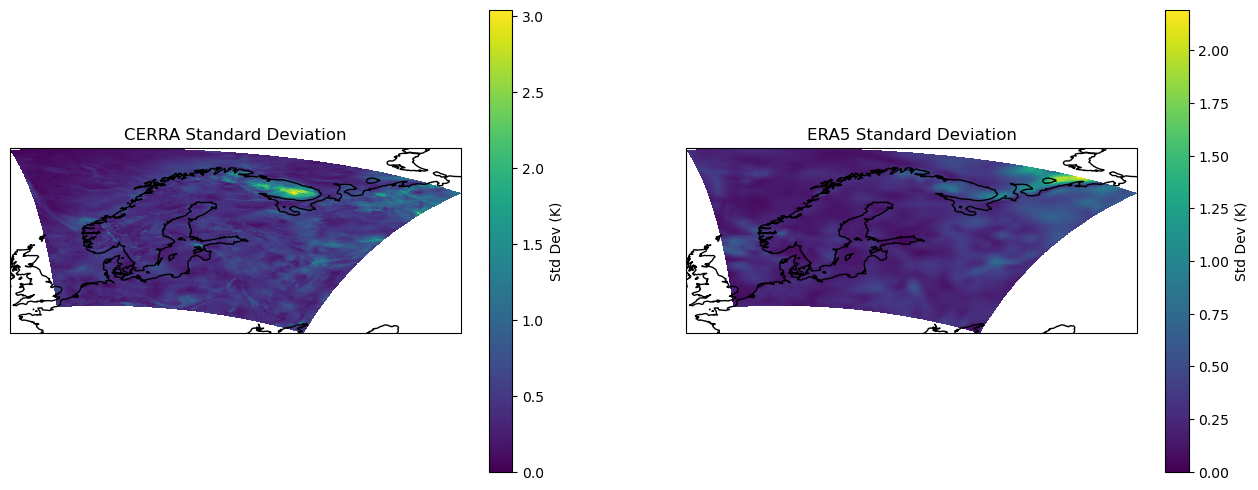

In [81]:
# Select a time index
time_idx = 10  # Arbitrary time step

fig, ax = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot CERRA Std
ds['t2m_cerra_std'].isel(valid_time=time_idx).plot(
    ax=ax[0], 
    x='longitude', y='latitude', 
    transform=ccrs.PlateCarree(), 
    cmap='viridis',
    vmin=0,
    cbar_kwargs={'label': 'Std Dev (K)'}
)
ax[0].set_title("CERRA Standard Deviation")

# Plot ERA5 Std
ds['t2m_era5_std'].isel(valid_time=time_idx).plot(
    ax=ax[1], 
    x='longitude', y='latitude', 
    transform=ccrs.PlateCarree(), 
    cmap='viridis',
    vmin=0,
    cbar_kwargs={'label': 'Std Dev (K)'}
)
ax[1].set_title("ERA5 Standard Deviation")

for a in ax:
    a.coastlines()

plt.show()